# Game Theory; 
How do we analyze human action?

## Backward Induction (การอนุมานย้อนกลับ)

### Foreward Thinking
$$\text{cause (present)}\Longrightarrow \text{effect (future)}$$

ตัวอย่าง: เพราะ สถานะการณ์ปัจจุบัน A (cause) ฉันจึงทำ B (effect).

### Backward Thinking

$$\text{effect (utility)} \Longrightarrow \text{cause (action)}$$

มนุษย์เป็นสิ่งมีชีวิตที่คิดถึงผลประโยชน์ในอนาคตด้วยข้อมูลที่ตนมี ก่อนเลือกที่จะลงมือทำ

ดังนั้น Backward Induction คือการคิดย้อนกลับโดยการดู ผลประโยชน์ ก่อน เพื่อหากลยุทธ์ตอบสนองที่ดีที่สุด (best responds)

## Scenario Example: Small Country Provokes Big Country

### Setup:
- Small Country ($S$): Knows it cannot win a war but wants to create chaos, provoke a reaction, or embolden allies.


- Big Country ($B$): Has overwhelming military power, but must decide how to respond.

### Goals:

- $S$ wants to:
    - Gain media coverage
    - Stir nationalist pride
    - Trigger external support or sanctions against B
    - Possibly draw B into a costly conflict
- $B$ wants to:
    - Maintain prestige
    - Avoid costly, drawn-out war
    - Prevent setting a precedent for future provocations

### Game Tree 

1. $S$ attacks $B$ (symbolic or low-level attack).
2. $B$ responds:
    - Overreact (crush S) → costly war, global condemnation
    - Ignore → looks weak, emboldens future attacks
    - Targeted response → minimal cost, unclear signal

In [1]:
# Re-import necessary libraries after kernel reset
import networkx as nx
import matplotlib.pyplot as plt

import numpy as np
import seaborn as sns
import pandas as pd

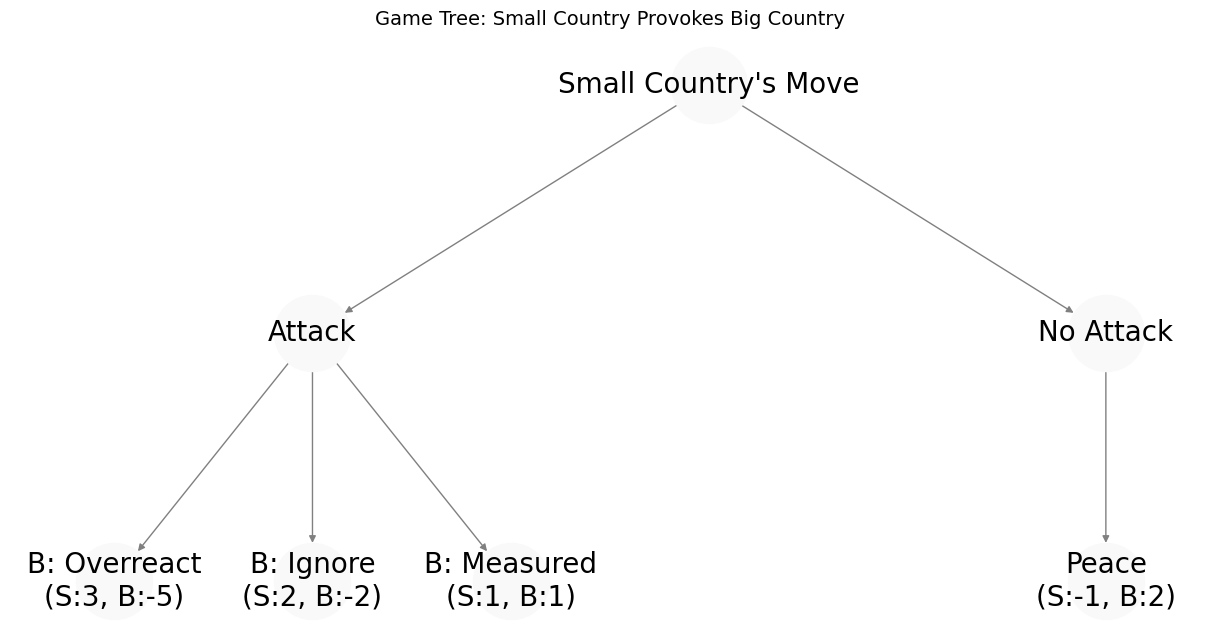

In [2]:
# Create a directed graph
G = nx.DiGraph()

# Add nodes with labels
G.add_node("Start", label="Small Country's Move")
G.add_node("Attack", label="Attack")
G.add_node("NoAttack", label="No Attack")

G.add_node("Overreact", label="B: Overreact\n(S:3, B:-5)")
G.add_node("Ignore", label="B: Ignore\n(S:2, B:-2)")
G.add_node("Measured", label="B: Measured\n(S:1, B:1)")
G.add_node("Peace", label="Peace\n(S:-1, B:2)")

# Add edges
G.add_edges_from([
    ("Start", "Attack"),
    ("Start", "NoAttack"),
    ("Attack", "Overreact"),
    ("Attack", "Ignore"),
    ("Attack", "Measured"),
    ("NoAttack", "Peace")
])

# Set layout
pos = {
    "Start": (0, 3),
    "Attack": (-2, 2),
    "NoAttack": (2, 2),
    "Overreact": (-3, 1),
    "Ignore": (-2, 1),
    "Measured": (-1, 1),
    "Peace": (2, 1)
}

# Draw the tree
plt.figure(figsize=(12, 6))
nx.draw(G, pos, with_labels=False, arrows=True, node_size=3000, node_color="#f9f9f9", edge_color='gray')
labels = nx.get_node_attributes(G, 'label')
nx.draw_networkx_labels(G, pos, labels, font_size=20, font_family="sans-serif")

plt.title("Game Tree: Small Country Provokes Big Country", fontsize=14)
plt.axis('off')
plt.show()


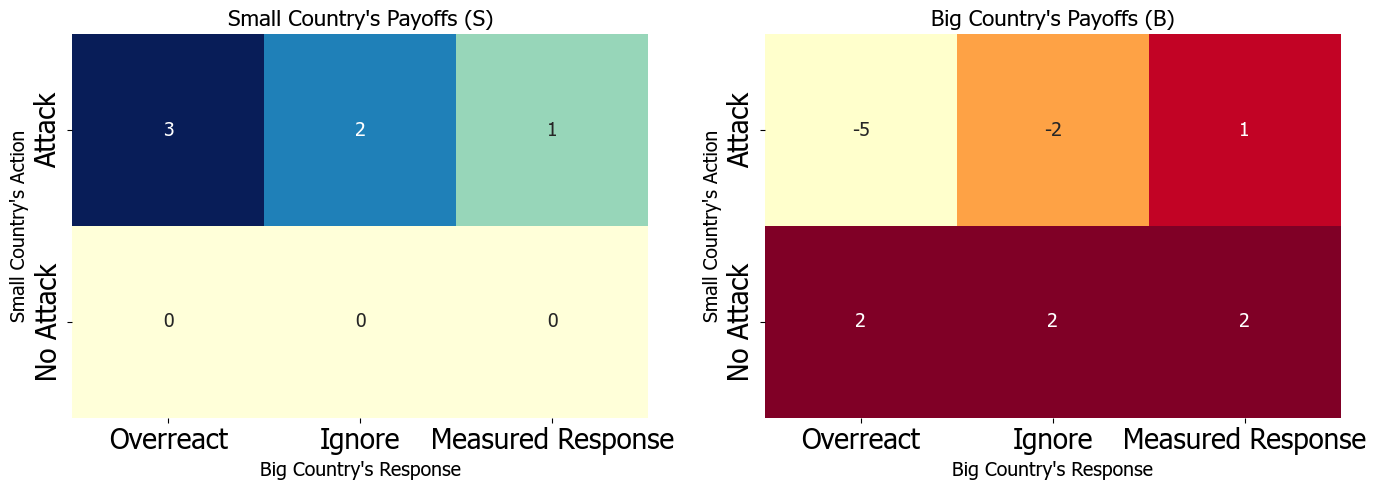

In [3]:
# Use Tahoma font for consistency with user's preference
plt.rcParams["font.family"] = "Tahoma"

# Define payoff matrix for a single-shot game
actions_S = ["Attack", "No Attack"]
responses_B = ["Overreact", "Ignore", "Measured Response"]

# Payoffs in the form: (S_payoff, B_payoff)
payoffs = {
    ("Attack", "Overreact"): (3, -5),
    ("Attack", "Ignore"): (2, -2),
    ("Attack", "Measured Response"): (1, 1),
    ("No Attack", "Overreact"): (0, 2),
    ("No Attack", "Ignore"): (0, 2),
    ("No Attack", "Measured Response"): (0, 2),
}

# Create separate payoff matrices
S_matrix = np.array([[payoffs[(s, b)][0] for b in responses_B] for s in actions_S])
B_matrix = np.array([[payoffs[(s, b)][1] for b in responses_B] for s in actions_S])

# Convert to DataFrames for seaborn heatmap
S_df = pd.DataFrame(S_matrix, index=actions_S, columns=responses_B)
B_df = pd.DataFrame(B_matrix, index=actions_S, columns=responses_B)

# Plotting side-by-side heatmaps with increased font size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(S_df, annot=True, fmt="d", cmap="YlGnBu", ax=axes[0], cbar=False, annot_kws={"size": 14})
axes[0].set_title("Small Country's Payoffs (S)", fontsize=16)
axes[0].set_xlabel("Big Country's Response", fontsize=14)
axes[0].set_ylabel("Small Country's Action", fontsize=14)
axes[0].tick_params(axis='both', labelsize=20)

sns.heatmap(B_df, annot=True, fmt="d", cmap="YlOrRd", ax=axes[1], cbar=False, annot_kws={"size": 14})
axes[1].set_title("Big Country's Payoffs (B)", fontsize=16)
axes[1].set_xlabel("Big Country's Response", fontsize=14)
axes[1].set_ylabel("Small Country's Action", fontsize=14)
axes[1].tick_params(axis='both', labelsize=20)

plt.tight_layout()
plt.show()


# Equilibrium

In [4]:
import nashpy as nash

In [5]:
# Define the payoff matrices again, with S (row player), B (column player)
# S_matrix: Small country payoffs
# B_matrix: Big country payoffs
S_matrix = np.array([
    [3, 2, 1],  # Attack: Overreact, Ignore, Measured Response
    [0, 0, 0]   # No Attack
])

B_matrix = np.array([
    [-5, -2, 1],  # Attack: Overreact, Ignore, Measured Response
    [2, 2, 2]     # No Attack
])

# Create the game
game = nash.Game(S_matrix, B_matrix)

# Compute Nash equilibria using support enumeration
equilibria = list(game.support_enumeration())

# Format results
equilibrium_results = []
for eq in equilibria:
    s_strategy, b_strategy = eq
    equilibrium_results.append({
        "Small Country Strategy": s_strategy.round(2),
        "Big Country Strategy": b_strategy.round(2),
        "Expected Payoff (S)": game[s_strategy, b_strategy][0].round(2),
        "Expected Payoff (B)": game[s_strategy, b_strategy][1].round(2)
    })

equilibrium_results


[{'Small Country Strategy': array([1., 0.]),
  'Big Country Strategy': array([0., 0., 1.]),
  'Expected Payoff (S)': np.float64(1.0),
  'Expected Payoff (B)': np.float64(1.0)}]